# Anomaly Detection on mlg-ulb Credit Card Fraud Data

## 1. Problem Framing

Anomaly detection is the identification of data points that do not align with expected values. By detecting such inconsistencies in a data set, valuable insights can be drawn. In the context of this project, these anomalies can help identify fraudulent credit card transactions.

In unsupervised learning, patterns and structure are inferred directly from the data without the use of labeled outcomes. In contrast, supervised learning relies on predefined labels and aims to learn a mapping between input features and those labels.

Although the dataset we are using includes a `class` feature that indicates if the transaction is legitimate (0) or fraudulent (1), this project is framed as an unsupervised anomaly detection problem. The explored detection methods are designed to identify anomalies without relying on labelled data during training.


This approach better represents real-world fraud detection scenarios, where fraudulent activities are evolving and not fully labeled in advance. Thus, the `class` labels will be used in the evaluation, not the training of our unsupervised methods. Therefore, this problem is explicitly treated as an unsupervised anomaly detection task.

## 2. Detection Methods

### Preprocessing

The `Class` label was removed from training to maintain an unsupervised learning framework, but retained for evaluation. The `Time` feature was removed as it represents a relative timestamp with limited standalone predictive value. Features were standardized using z-score normalization to ensure consistent scaling across dimensions.

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def get_dataset(filename="archive/creditcard.csv"):
    df = pd.read_csv(filename)

    # Identify any missing values:
    values = df.isnull().sum()
    print(values[values > 0])

    # Unsupervised, so drop Class in X
    df_dropped = df.drop(columns=['Class', 'Time'])
    y = df['Class']

    # These samples are already time-ordered, so we simply split them such that
    # train = transactions in the past, test = transactions in the future
    split_idx = int(len(df) * 0.8)
    X_train = df_dropped.iloc[:split_idx]
    X_test = df_dropped.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # Normalize the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

### Statistical Method: Moving Average

The moving average is a statistical method of anomaly detection that computes a distance-based anomaly score using uses the mean, $\mu$, and the standard deviation, $\sigma$ of a sliding window of time-ordered transactions. The anomaly score for the $i^{\mathrm{th}}$ transaction is

$\text{score}_i = \sqrt{\sum_{j=1}^{d} \left( \frac{x_{ij} - \mu_j}{\sigma_j} \right)^2}$

Where $d$ is the number of features in the window, $x_{ij}$ is the value of feature $j$ for transaction $i$, and the score is the euclidean distance of the z-score. 

In [13]:
import numpy as np
import pandas as pd

def moving_average_detector(
    X_train,
    X_test,
    y_test,
    window_size=50,
    quantile=0.99
):
    # Create DataFrames
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    #########
    # TRAIN #
    #########

    train_mean = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    train_std = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    train_z = (X_train_df - train_mean) / train_std
    train_scores = np.sqrt((train_z ** 2).sum(axis=1))

    # Threshold from train only
    threshold = train_scores.quantile(quantile)

    ########
    # TEST #
    ########

    # Give the test set the recent past from training
    X_combined = pd.concat(
        [X_train_df.iloc[-(window_size - 1):], X_test_df],
        ignore_index=True
    )

    test_mean = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    test_std = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    test_z = (X_combined - test_mean) / test_std
    test_scores_all = np.sqrt((test_z ** 2).sum(axis=1))

    # Drop the train scores, keep test scores. The higher the score, the more
    # likely the sample is an anomaly.
    test_scores = test_scores_all.iloc[window_size - 1:].reset_index(drop=True)

    # Binary predictions
    y_pred = (test_scores > threshold).astype(int)

    # Replace the current index with 0, 1, 2, etc
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

X_train, X_test, y_train, y_test = get_dataset()

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=100000,
    quantile=0.9
)

Series([], dtype: int64)


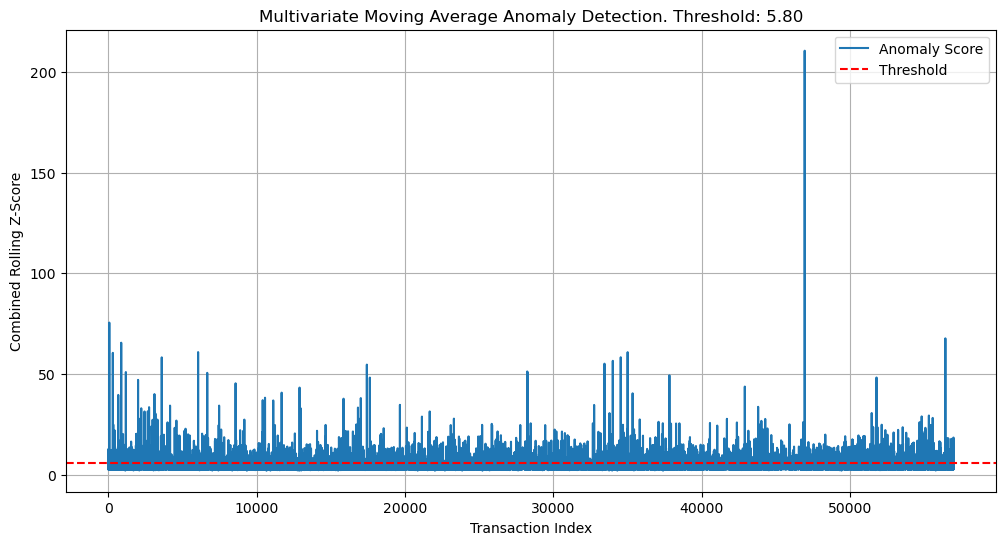

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ma_output['scores'], label='Anomaly Score')
plt.axhline(y=ma_output['threshold'], color='r', linestyle='--', label='Threshold')
plt.xlabel('Transaction Index')
plt.ylabel('Combined Rolling Z-Score')
plt.title(f"Multivariate Moving Average Anomaly Detection. Threshold: {ma_output['threshold']:.2f}")
plt.legend()
plt.grid(True)
plt.show()

### Distance-based Method: kNN Anomaly Detection

This implements k-Nearest Neighbors (kNN) as a distance-based anomaly detection method, where the anomaly score is defined as the distance to the k-th nearest neighbor. Since anomalies are expected to lie in low-density regions, they require a larger radius to reach k neighbors, resulting in higher scores. We use Euclidean distance because the features are already standardized, making distances meaningful across dimensions. The anomaly threshold is set using a quantile of the training scores, ensuring it is based only on normal behavior and can be tuned to control the precision–recall tradeoff.

In [8]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# A KNN built for unsupervised anomaly detection using largest scoring (Kth nearest neighbor)
def knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=5,
    quantile=0.99
):
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    # Assume data is already scaled in preprocessing
    X_train_scaled = X_train_df
    X_test_scaled = X_test_df

    # Added optimization with n_jobs
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_scaled)

    distances, _ = knn.kneighbors(X_test_scaled)

    # Distance to k-th nearest training neighbor
    test_scores = pd.Series(distances[:, -1])

    # Threshold from train scores only
    train_distances, _ = knn.kneighbors(X_train_scaled)
    train_scores = pd.Series(train_distances[:, -1])
    threshold = train_scores.quantile(quantile)

    y_pred = (test_scores > threshold).astype(int)

    # realign index
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

### ML Method: Isolation Forest

Isolation Forest builds many random trees that repeatedly split the data along randomly chosen features and thresholds, isolating points in the process. Anomalies are isolated in fewer splits (shorter path lengths), so they receive higher anomaly scores.

In [ ]:
from sklearn.ensemble import IsolationForest

def isolation_forest_detector(
        X_train,
        X_test,
        y_test,
        contamination=0.01
):

    #########
    # TRAIN #
    #########

    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)

    ########
    # TEST #
    ########

    # More positive = more likely to be fraudulent
    scores = -model.decision_function(X_test)

    y_pred = model.predict(X_test)
    y_pred = (y_pred == -1).astype(int)

    y_true = y_test.reset_index(drop=True)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores
    }

X_train, X_test, y_train, y_test = get_dataset()

if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.01
)   

Series([], dtype: int64)


### Deep Learning Method: Autoencoder

An autoencoder is a neural network trained to reconstruct its input, learning a compressed representation of normal data. Points with high reconstruction error (i.e., poorly reconstructed) are flagged as anomalies.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def pytorch_autoencoder_detector(
    X_train,
    X_test,
    y_train,
    y_test,
    quantile=0.99,
    epochs=20,
    batch_size=256,
    lr=1e-3
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Train only on normal transactions
    y_train_reset = y_train.reset_index(drop=True)
    X_train_normal = X_train[y_train_reset == 0]

    X_train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)
    train_loader = DataLoader(
        TensorDataset(X_train_tensor),
        batch_size=batch_size,
        shuffle=True
    )

    input_dim = X_train.shape[1]
    model = Autoencoder(input_dim).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for (batch,) in train_loader:
            batch = batch.to(device)

            reconstructed = model(batch)
            loss = criterion(reconstructed, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader):.6f}")

    # Compute threshold using normal training reconstruction errors
    model.eval()
    with torch.no_grad():
        train_tensor = torch.tensor(X_train_normal, dtype=torch.float32).to(device)
        train_recon = model(train_tensor)
        train_errors = torch.mean((train_tensor - train_recon) ** 2, dim=1)
        train_errors = train_errors.cpu().numpy()

    threshold = np.quantile(train_errors, quantile)

    # Compute test reconstruction errors
    with torch.no_grad():
        test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        test_recon = model(test_tensor)
        scores = torch.mean((test_tensor - test_recon) ** 2, dim=1)
        scores = scores.cpu().numpy()

    y_pred = (scores > threshold).astype(int)
    y_true = y_test.reset_index(drop=True)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores,
        "threshold": threshold,
        "model": model
    }

## 3. Threshold Optimization

In [5]:
#!pip install mlflow

import mlflow

# setup mlflow experiment
mlflow.set_experiment("Credit Card Fraud - Anomaly Detection")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1777002793619, experiment_id='1', last_update_time=1777002793619, lifecycle_stage='active', name='Credit Card Fraud - Anomaly Detection', tags={}, trace_location=None, workspace='default'>

### 3.1 Moving Average Threshold Optimization

#### 3.1.1 Window Tuning

In [31]:
def tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through window sizes to evaluate performance
    for window_size in window_sizes:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{quantile}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "window_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,50,0.99,13.443325,0.074941,0.426667,0.127490,0.006944,56492,395,43,32,427
1,100,0.99,14.736443,0.070588,0.400000,0.120000,0.006944,56492,395,45,30,425
2,500,0.99,15.910252,0.070686,0.453333,0.122302,0.007858,56440,447,41,34,481
3,1000,0.99,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
4,5000,0.99,15.768208,0.078775,0.480000,0.135338,0.007401,56466,421,39,36,457


Best window size: 1000


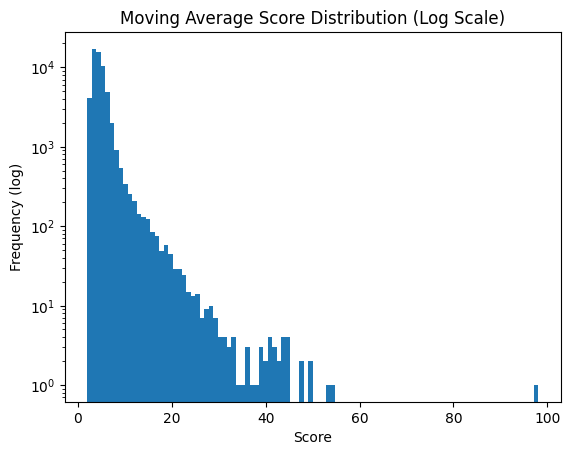

In [35]:
# Run window tuning
window_sizes = [50, 100, 500, 1000, 5000]

X_train, X_test, y_train, y_test = get_dataset()

ma_window_results_df = tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
)

display(ma_window_results_df)

best_window = int(ma_window_results_df.sort_values(by="f1", ascending=False).iloc[0]["window_size"])
print("Best window size:", best_window)

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=0.99
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.yscale("log")
plt.title("Moving Average Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

Smaller window sizes are more sensitive to local fluctuations, resulting in higher recall but increased false positives. Larger window sizes smooth the data more heavily, reducing false positives but also missing some anomalies. A window size of 1000 provides the best trade-off, capturing meaningful deviations while maintaining stability in the anomaly scores.

#### 3.1.2 Threshold Tuning

In [33]:
def tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{q}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,1000,0.950,8.087997,0.023180,0.853333,0.045134,0.047410,54190,2697,11,64,2761
1,1000,0.975,10.732168,0.042569,0.760000,0.080622,0.022536,55605,1282,18,57,1339
2,1000,0.990,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
3,1000,0.995,20.298908,0.053659,0.146667,0.078571,0.003410,56693,194,64,11,205
4,1000,0.999,32.124583,0.000000,0.000000,0.000000,0.000721,56846,41,75,0,41


Best quantile: 0.99
Best threshold: 15.94176139138372


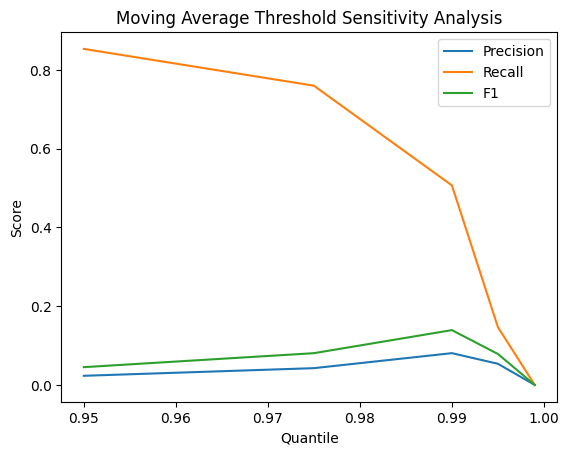

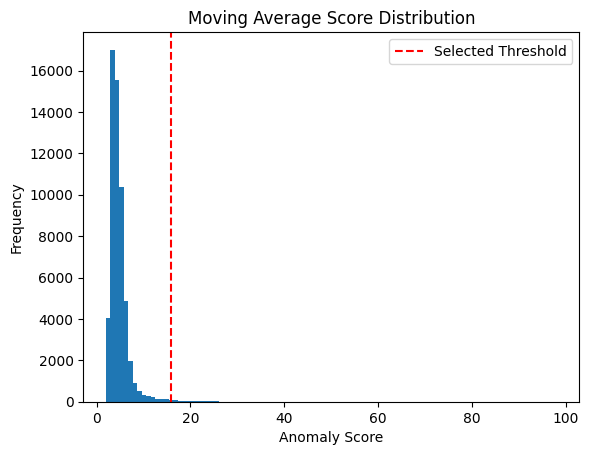

In [36]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

X_train, X_test, y_train, y_test = get_dataset()

ma_threshold_results_df = tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size=best_window,
    quantiles=quantiles
)

display(ma_threshold_results_df)

# Select best threshold
best_row = ma_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_ma_quantile = best_row["quantile"]
best_ma_threshold = best_row["threshold"]

print("Best quantile:", best_ma_quantile)
print("Best threshold:", best_ma_threshold)

# Sensitivity plot
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["precision"], label="Precision")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["recall"], label="Recall")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("Moving Average Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=best_ma_quantile
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.axvline(best_ma_threshold, linestyle="--", label="Selected Threshold", color="r")
plt.title("Moving Average Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The moving average model exhibits a clear sensitivity to threshold selection, with performance varying significantly across quantiles. Lower thresholds (like 0.95) result in high recall by identifying most fraudulent transactions, but introduce a large number of false positives due to the method’s sensitivity to local fluctuations. As the threshold increases, the model becomes more selective, reducing false positives and improving precision, but at the cost of missing fraudulent activity.

The anomaly score distribution is heavily skewed, with the majority of transactions concentrated at low scores and a gradual tail of higher values corresponding to deviations from the rolling statistical baseline. Unlike kNN, where anomalies are defined by spatial isolation, the moving average method captures temporal deviations, resulting in a smoother but less sharply separated tail. The selected threshold at the 0.99 quantile lies near the onset of this tail, capturing significant deviations while avoiding excessive noise from normal variations.

From a performance perspective, this threshold yields the highest F1-score, indicating the best compromise between detecting fraud and limiting false positives. Lower thresholds are overly sensitive, while higher thresholds become too conservative and fail to detect meaningful anomalies.

From a business standpoint, the cost of missing fraudulent transactions outweighs the inconvenience of false positives. However, the moving average method tends to produce more false positives due to its reliance on local statistics, making threshold selection particularly important. The chosen threshold therefore reflects a balance between maintaining acceptable recall and ensuring the system remains operationally feasible

### 3.2 kNN Threshold Optimization

#### 3.2.1 k Tuning

In [9]:
def tune_knn_k(
    X_train,
    X_test,
    y_test,
    k_values,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through k values to evaluate performance
    for k in k_values:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{quantile}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "k_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)

            results.append({
                "k": k,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,k,quantile,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives
0,3,0.99,5.893125,0.033708,0.800000,0.064690,0.034452,344,3,12
1,5,0.99,6.563285,0.041522,0.800000,0.078947,0.027742,277,3,12
2,10,0.99,7.947128,0.046392,0.600000,0.086124,0.018528,185,6,9
3,20,0.99,9.477530,0.065789,0.666667,0.119760,0.014221,142,5,10
4,50,0.99,12.077962,0.067961,0.466667,0.118644,0.009614,96,8,7


Best k: 20


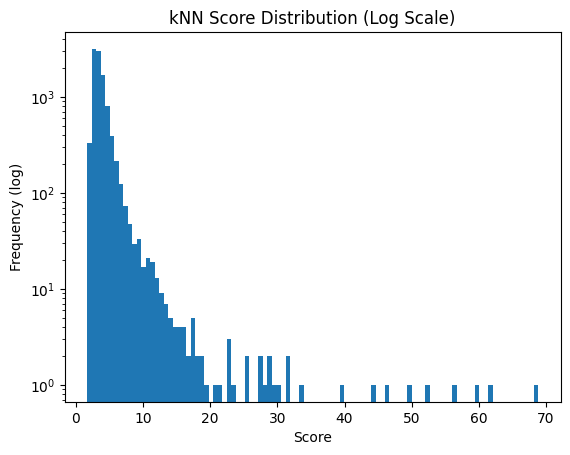

In [27]:
# Run tuning on smaller subset of dataset
X_train, X_test, y_train, y_test = get_dataset()

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

k_values = [3, 5, 10, 20, 50]

k_results_df = tune_knn_k(
    X_train_small,
    X_test_small,
    y_test_small,
    k_values,
    quantile=0.99
)

# Display the results comparing each k value
display(k_results_df)

best_k = int(k_results_df.sort_values(by="f1", ascending=False).iloc[0]["k"])
print("Best k:", best_k)

output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=0.99
)

# Plot the score distribution
plt.hist(output["scores"], bins=100)
plt.yscale("log")
plt.title("kNN Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

We selected k=20 because it produced the highest F1-score during tuning, balancing recall with a lower false positive rate. Lower k values detected more fraud but produced many more false positives, while larger k values reduced false positives but missed more fraud. Low precision is expected, as only around 0.17% of dataset is fraud, so any false positives at all greatly lower the precision score due to class imbalance.

#### 3.2.2 KNN Threshold Optimization

In [18]:
def tune_knn_threshold(
    X_train,
    X_test,
    y_test,
    k,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{q}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            # Additional metrics for better analysis
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "k": k,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

,k,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,20,0.950,5.175620,0.016009,1.000000,0.031513,0.092339,9063,922,0,15,937
1,20,0.975,6.532754,0.034230,0.933333,0.066038,0.039559,9590,395,1,14,409
2,20,0.990,9.477530,0.065789,0.666667,0.119760,0.014221,9843,142,5,10,152
3,20,0.995,12.134438,0.000000,0.000000,0.000000,0.007611,9909,76,15,0,76
4,20,0.999,23.207579,0.000000,0.000000,0.000000,0.002203,9963,22,15,0,22


Best quantile: 0.99
Best threshold: 9.477529599112113


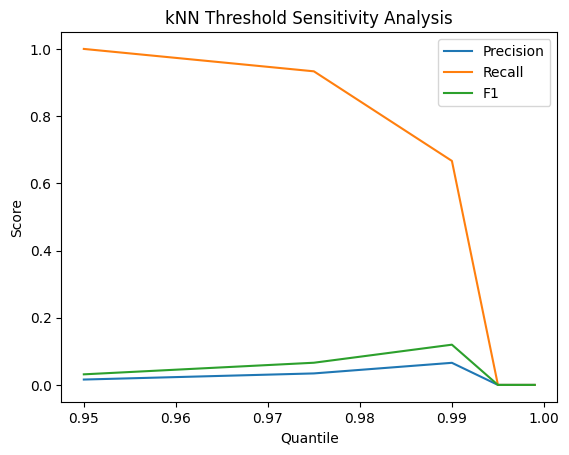

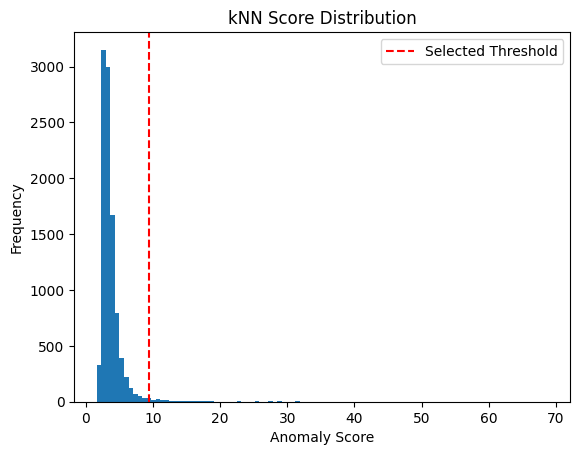

In [26]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

knn_threshold_results_df = tune_knn_threshold(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantiles=quantiles
)

display(knn_threshold_results_df)

# Select best threshold
best_row = knn_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_quantile = best_row["quantile"]
best_threshold = best_row["threshold"]

print("Best quantile:", best_quantile)
print("Best threshold:", best_threshold)

# Sensitivity plot
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["precision"], label="Precision")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["recall"], label="Recall")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("kNN Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=best_quantile
)

plt.hist(output["scores"], bins=100)
plt.axvline(best_threshold, linestyle="--", label="Selected Threshold", color = 'r')
plt.title("kNN Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The threshold sensitivity analysis reveals a clear trade-off between recall and false positives in the moving average model. Lower thresholds (e.g., 0.95) achieve high recall by detecting most fraudulent transactions but generate many false positives. As the threshold increases, precision improves and the false positive rate decreases, but recall drops sharply. At very high thresholds, the model becomes too conservative and fails to detect fraud.

The anomaly score distribution explains this behavior, as scores are highly skewed with most transactions clustered at low values and a long tail representing abnormal deviations. The selected threshold at the 0.99 quantile lies near the start of this tail, capturing meaningful anomalies while limiting noise from normal variations.

This threshold produces the highest F1-score, indicating the best balance between precision and recall. Lower thresholds are overly sensitive, while higher thresholds are too restrictive, making the selected value a practical compromise based on both the score distribution and performance metrics.

From a business perspective, missing fraudulent transactions is significantly more costly than incorrectly flagging legitimate ones, as undetected fraud can lead to costly things like direct financial loss. However, an excessive number of false positives can overwhelm fraud investigation systems and increase operational costs. The selected threshold balances these by maintaining strong recall to capture a meaningful portion of fraud, while keeping the false positive rate at a manageable level for further review processes.

In [23]:
runs = mlflow.search_runs()
knn_runs = runs[runs["params.method"] == "kNN"]

display(knn_runs[[
    "params.stage",
    "params.k",
    "params.quantile",
    "params.threshold",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.false_positive_rate"
]])

knn_runs.to_csv("knn_mlflow_logs.csv", index=False)

,params.stage,params.k,params.quantile,params.threshold,metrics.precision,metrics.recall,metrics.f1,metrics.false_positive_rate
0,k_tuning,50,0.99,12.077961764124698,0.067961,0.466667,0.118644,0.009614
1,k_tuning,20,0.99,9.477529599112113,0.065789,0.666667,0.119760,0.014221
2,k_tuning,10,0.99,7.947127657007068,0.046392,0.600000,0.086124,0.018528
3,k_tuning,5,0.99,6.563285460290048,0.041522,0.800000,0.078947,0.027742
4,k_tuning,3,0.99,5.893124508102291,0.033708,0.800000,0.064690,0.034452
5,threshold_tuning,20,0.999,23.207578524796848,0.000000,0.000000,0.000000,0.002203
6,threshold_tuning,20,0.995,12.13443816839351,0.000000,0.000000,0.000000,0.007611
7,threshold_tuning,20,0.99,9.477529599112113,0.065789,0.666667,0.119760,0.014221
8,threshold_tuning,20,0.975,6.532754164081307,0.034230,0.933333,0.066038,0.039559
9,threshold_tuning,20,0.95,5.1756196035470445,0.016009,1.000000,0.031513,0.092339


### 3.3 Isolated Forest Optimization

#### 3.3.1 Contamination Tuning

In [ ]:
def tune_isolation_forest_contamination(
    X_train,
    X_test,
    y_test,
    contamination_values
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through contamination values to evaluate threshold performance
    for c in contamination_values:

        # MLFlow logging
        with mlflow.start_run(run_name=f"IsolationForest_c{c}"):

            # Run Isolation Forest
            output = isolation_forest_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                contamination=c
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Isolation Forest")
            mlflow.log_param("stage", "contamination_tuning")
            mlflow.log_param("contamination", c)

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            # Additional metrics for better analysis
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "contamination": c,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

In [ ]:
# Run contamination tuning
contamination_values = [0.005, 0.01, 0.02, 0.03, 0.05]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

if_contamination_results_df = tune_isolation_forest_contamination(
    X_train_small,
    X_test_small,
    y_test_small,
    contamination_values=contamination_values
)

display(if_contamination_results_df)

# Select best contamination value
best_row = if_contamination_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_contamination = best_row["contamination"]

print("Best contamination:", best_contamination)

# Sensitivity plot
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["precision"], label="Precision")
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["recall"], label="Recall")
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["f1"], label="F1")
plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Isolation Forest Contamination Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = isolation_forest_detector(
    X_train=X_train_small,
    X_test=X_test_small,
    y_test=y_test_small,
    contamination=best_contamination
)

plt.hist(output["scores"], bins=100)
plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

The contamination sensitivity analysis shows that Isolation Forest performance depends strongly on how aggressively anomalies are flagged. At low contamination values, the model is too conservative and misses most fraudulent transactions. Increasing contamination improves recall, but also increases false positives. This trend reflects the trade-off between detecting more fraud and maintaining a manageable number of false alarms.

The anomaly scores form a relatively smooth distribution with a gradual tail, rather than a sharply separated boundary. This makes threshold selection less about finding a clear cutoff and more about choosing an appropriate proportion of points to classify as anomalous.

A contamination value of 0.03 achieves the highest F1-score, providing the best balance between precision and recall. Lower values fail to capture enough fraud, while higher values become overly permissive and introduce excessive false positives.

From a practical standpoint, missing fraud is more costly than false alarms, but too many flagged transactions increase operational burden. The selected contamination level reflects a balance between these constraints, maintaining useful detection performance while keeping the number of alerts manageable.

### 3.4 Autoencoder

#### 3.4.1 Quantile Tuning

In [48]:
def tune_autoencoder_quantile(
    X_train,
    X_test,
    y_train,
    y_test,
    quantile_values,
    epochs=30,
    batch_size=256,
    lr=1e-3
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantile values to evaluate threshold performance
    for q in quantile_values:

        # MLflow logging
        with mlflow.start_run(run_name=f"Autoencoder_q{q}"):

            # Run PyTorch Autoencoder
            output = pytorch_autoencoder_detector(
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                quantile=q,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]
            threshold = output["threshold"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

            # MLflow logging
            mlflow.log_param("method", "PyTorch Autoencoder")
            mlflow.log_param("stage", "quantile_tuning")
            mlflow.log_param("quantile", q)
            mlflow.log_param("epochs", epochs)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("learning_rate", lr)
            mlflow.log_metric("threshold", threshold)

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "quantile": q,
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Epoch 1/30, Loss: 1.028323
Epoch 2/30, Loss: 0.878572
Epoch 3/30, Loss: 0.768643
Epoch 4/30, Loss: 0.675725
Epoch 5/30, Loss: 0.600272
Epoch 6/30, Loss: 0.559706
Epoch 7/30, Loss: 0.532586
Epoch 8/30, Loss: 0.514458
Epoch 9/30, Loss: 0.500954
Epoch 10/30, Loss: 0.490675
Epoch 11/30, Loss: 0.481857
Epoch 12/30, Loss: 0.476064
Epoch 13/30, Loss: 0.468483
Epoch 14/30, Loss: 0.462926
Epoch 15/30, Loss: 0.457868
Epoch 16/30, Loss: 0.453322
Epoch 17/30, Loss: 0.449964
Epoch 18/30, Loss: 0.445837
Epoch 19/30, Loss: 0.441491
Epoch 20/30, Loss: 0.437263
Epoch 21/30, Loss: 0.433573
Epoch 22/30, Loss: 0.429853
Epoch 23/30, Loss: 0.427332
Epoch 24/30, Loss: 0.422802
Epoch 25/30, Loss: 0.419821
Epoch 26/30, Loss: 0.416696
Epoch 27/30, Loss: 0.414699
Epoch 28/30, Loss: 0.412688
Epoch 29/30, Loss: 0.410203
Epoch 30/30, Loss: 0.408362
Epoch 1/30, Loss: 1.042945
Epoch 2/30, Loss: 0.853959
Epoch 3/30, Loss: 0.739585
Epoch 4/30, Loss: 0.650939
Epoch 5/30, Loss: 0.600465
Epoch 6/30, Loss: 0.574171
Epoch 7

,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,0.950,0.824716,0.009709,1.000000,0.019231,0.153230,8455,1530,0,15,1545
1,0.970,1.219812,0.019943,0.933333,0.039052,0.068903,9297,688,1,14,702
2,0.980,1.457574,0.022965,0.733333,0.044534,0.046870,9517,468,4,11,479
3,0.990,2.447256,0.023041,0.333333,0.043103,0.021232,9773,212,10,5,217
4,0.995,3.891008,0.029630,0.266667,0.053333,0.013120,9854,131,11,4,135


Best quantile: 0.995


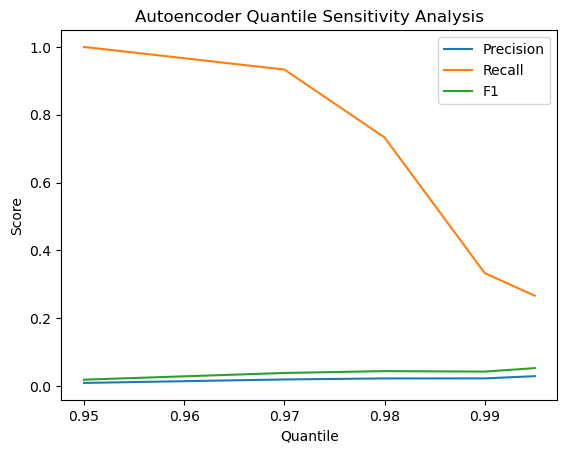

Epoch 1/30, Loss: 1.059171
Epoch 2/30, Loss: 0.912733
Epoch 3/30, Loss: 0.758408
Epoch 4/30, Loss: 0.669822
Epoch 5/30, Loss: 0.619809
Epoch 6/30, Loss: 0.584784
Epoch 7/30, Loss: 0.552670
Epoch 8/30, Loss: 0.530337
Epoch 9/30, Loss: 0.519029
Epoch 10/30, Loss: 0.510996
Epoch 11/30, Loss: 0.504386
Epoch 12/30, Loss: 0.497885
Epoch 13/30, Loss: 0.491948
Epoch 14/30, Loss: 0.485530
Epoch 15/30, Loss: 0.477854
Epoch 16/30, Loss: 0.470507
Epoch 17/30, Loss: 0.463524
Epoch 18/30, Loss: 0.456545
Epoch 19/30, Loss: 0.450664
Epoch 20/30, Loss: 0.443775
Epoch 21/30, Loss: 0.437990
Epoch 22/30, Loss: 0.432318
Epoch 23/30, Loss: 0.428302
Epoch 24/30, Loss: 0.424068
Epoch 25/30, Loss: 0.420909
Epoch 26/30, Loss: 0.418564
Epoch 27/30, Loss: 0.416544
Epoch 28/30, Loss: 0.414857
Epoch 29/30, Loss: 0.413090
Epoch 30/30, Loss: 0.411897


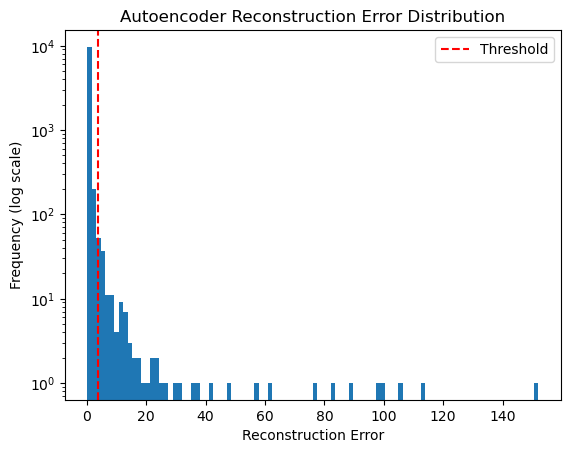

In [50]:
# Run quantile tuning
quantile_values = [0.95, 0.97, 0.98, 0.99, 0.995]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_train_small = y_train.iloc[:train_sample]
y_test_small = y_test.iloc[:test_sample]

ae_quantile_results_df = tune_autoencoder_quantile(
    X_train=X_train_small,
    X_test=X_test_small,
    y_train=y_train_small,
    y_test=y_test_small,
    quantile_values=quantile_values,
    epochs=30,
    batch_size=256,
    lr=1e-3
)

display(ae_quantile_results_df)

# Select best quantile value
best_row = ae_quantile_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_quantile = best_row["quantile"]

print("Best quantile:", best_quantile)

# Sensitivity plot
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["precision"], label="Precision")
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["recall"], label="Recall")
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("Autoencoder Quantile Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = pytorch_autoencoder_detector(
    X_train=X_train_small,
    X_test=X_test_small,
    y_train=y_train_small,
    y_test=y_test_small,
    quantile=best_quantile,
    epochs=30,
    batch_size=256,
    lr=1e-3
)

plt.hist(output["scores"], bins=100)
plt.axvline(output["threshold"], linestyle="--", color="red", label="Threshold")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.yscale("log")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

The autoencoder quantile sensitivity analysis shows a sharp trade-off. At lower quantiles (e.g., 0.95–0.97), recall is extremely high (near 1.0), meaning the model successfully detects almost all fraudulent transactions, but precision is very low, indicating a large number of false positives. As the quantile increases, the model becomes more conservative: recall drops significantly while precision improves slightly, reflecting the same fundamental trade-off between capturing fraud and limiting false alarms. The improvement in precision is relatively modest, suggesting the model struggles to clearly separate fraud from normal transactions.

The reconstruction error distribution is highly skewed, with a dense concentration of low-error (normal) samples and a long sparse tail of high-error points. There is no clear separation between normal and anomalous transactions, which makes threshold selection difficult. The threshold (based on the chosen quantile) effectively slices into this continuous distribution rather than separating two distinct clusters, meaning performance is highly sensitive to the chosen quantile.

The best F1-score occurs at a mid-range quantile (around 0.98–0.995), where the model achieves a balance between maintaining reasonable recall and slightly improving precision. Lower quantiles are too permissive and flood the system with false positives, while higher quantiles become too strict and miss a substantial portion of fraud cases.

From a practical perspective, the autoencoder behaves aggressively, prioritizing recall but at the cost of very low precision. This suggests that while it is effective at detecting anomalies broadly, it lacks strong discriminative power for this dataset. As a result, threshold tuning becomes critical, and the chosen quantile reflects a compromise between operational feasibility (manageable alert volume) and the need to detect as much fraud as possible.

## 4. Evaluation

In [ ]:
X_train, X_test, y_train, y_test = get_dataset()

print("Train moving average")
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=1000,
    quantile=0.99
)

print("Training kNN")
knn_output = knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=20,
    quantile=0.99
)

print("Training isolated forest")
if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.03
)

print("Train autoencoder")
ac_output = pytorch_autoencoder_detector(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    quantile=0.99,
    epochs=20
)

Series([], dtype: int64)
Epoch 1/20, Loss: 0.708997
Epoch 2/20, Loss: 0.576553
Epoch 3/20, Loss: 0.536832
Epoch 4/20, Loss: 0.514060
Epoch 5/20, Loss: 0.496940
Epoch 6/20, Loss: 0.487329
Epoch 7/20, Loss: 0.477198
Epoch 8/20, Loss: 0.465126
Epoch 9/20, Loss: 0.456816
Epoch 10/20, Loss: 0.451099
Epoch 11/20, Loss: 0.446789
Epoch 12/20, Loss: 0.443196
Epoch 13/20, Loss: 0.440728
Epoch 14/20, Loss: 0.438093
Epoch 15/20, Loss: 0.435967
Epoch 16/20, Loss: 0.434707
Epoch 17/20, Loss: 0.432656
Epoch 18/20, Loss: 0.431591
Epoch 19/20, Loss: 0.430551
Epoch 20/20, Loss: 0.429748


In [24]:
import matplotlib.pyplot as plt
import mlflow

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_binary_classifier(
    y_true,
    y_pred,
    scores,
    plot=True,
    log_mlflow=True,
    method_name="Binary Classifier",
    run_name=None
):
    """
    y_true: true labels, 0/1
    y_pred: predicted labels, 0/1
    scores: anomaly/fraud scores, higher = more likely positive
    """

    if run_name is None:
        run_name = f"{method_name}_evaluation"

    with mlflow.start_run(run_name=run_name) if log_mlflow else nullcontext():

        # Basic metrics
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        # Confusion matrix values
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

        # Curve metrics
        fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
        roc_auc = roc_auc_score(y_true, scores)

        pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, scores)
        avg_precision = average_precision_score(y_true, scores)

        # MLflow logging
        if log_mlflow:
            mlflow.log_param("method", method_name)
            mlflow.log_param("stage", "binary_classifier_evaluation")

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", false_positive_rate)

            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_positives", tp + fp)

            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("average_precision", avg_precision)

        results = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positive_rate": false_positive_rate,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "roc_auc": roc_auc,
            "average_precision": avg_precision,
            "roc_curve": {
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": roc_thresholds
            },
            "pr_curve": {
                "precision": pr_precision,
                "recall": pr_recall,
                "thresholds": pr_thresholds
            }
        }

        if plot:
            # Confusion matrix
            fig_cm, ax_cm = plt.subplots()
            ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax_cm)
            ax_cm.set_title(f"Confusion Matrix - {method_name}")

            if log_mlflow:
                mlflow.log_figure(fig_cm, "confusion_matrix.png")

            plt.show()

            # ROC curve
            fig_roc, ax_roc = plt.subplots()
            ax_roc.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
            ax_roc.plot([0, 1], [0, 1], linestyle="--")
            ax_roc.set_xlabel("False Positive Rate")
            ax_roc.set_ylabel("True Positive Rate / Recall")
            ax_roc.set_title(f"ROC Curve - {method_name}")
            ax_roc.legend()
            ax_roc.grid(True)

            if log_mlflow:
                mlflow.log_figure(fig_roc, "roc_curve.png")

            plt.show()

            # Precision-recall curve
            fig_pr, ax_pr = plt.subplots()
            ax_pr.plot(pr_recall, pr_precision, label=f"AP = {avg_precision:.3f}")
            ax_pr.set_xlabel("Recall")
            ax_pr.set_ylabel("Precision")
            ax_pr.set_title(f"Precision-Recall Curve - {method_name}")
            ax_pr.legend()
            ax_pr.grid(True)

            if log_mlflow:
                mlflow.log_figure(fig_pr, "precision_recall_curve.png")

            plt.show()

        return results

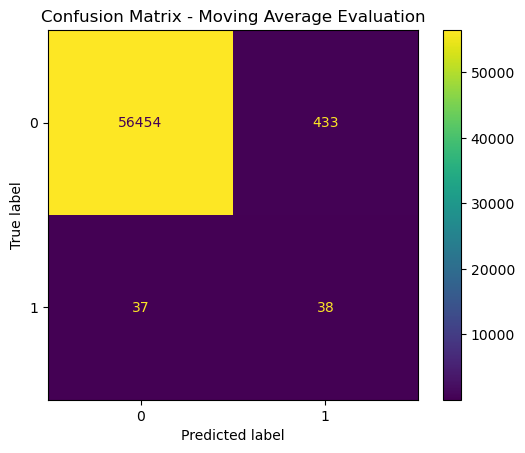

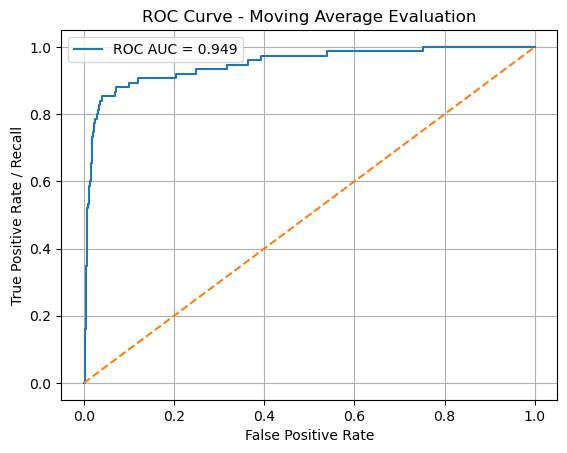

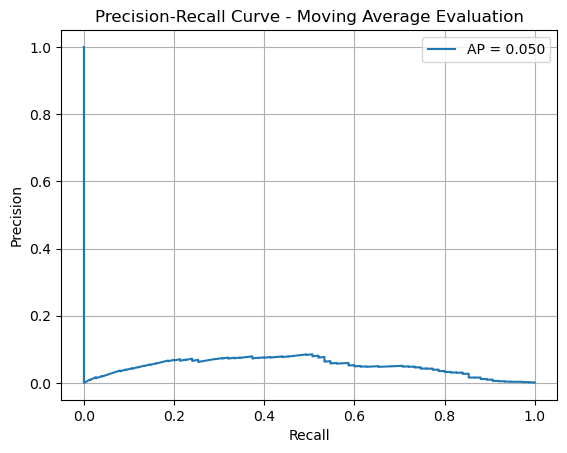

In [25]:
ma_results = evaluate_binary_classifier(
    ma_output['y_true'], 
    ma_output['y_pred'], 
    ma_output['scores'],
    method_name="Moving Average Evaluation"
) 

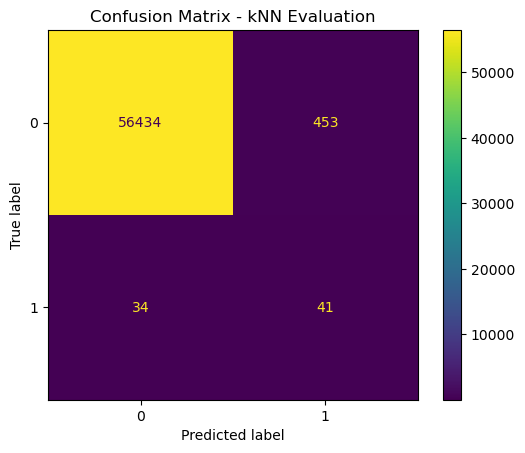

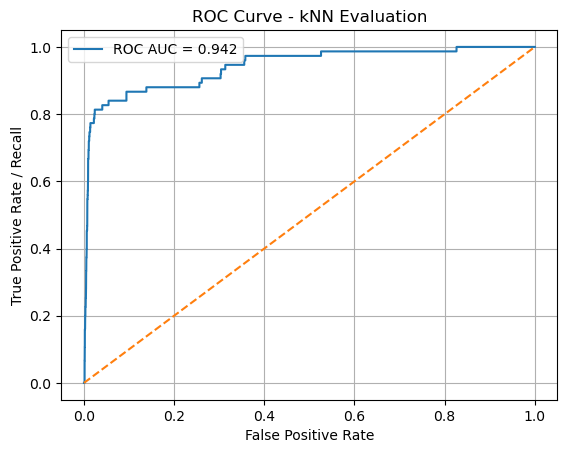

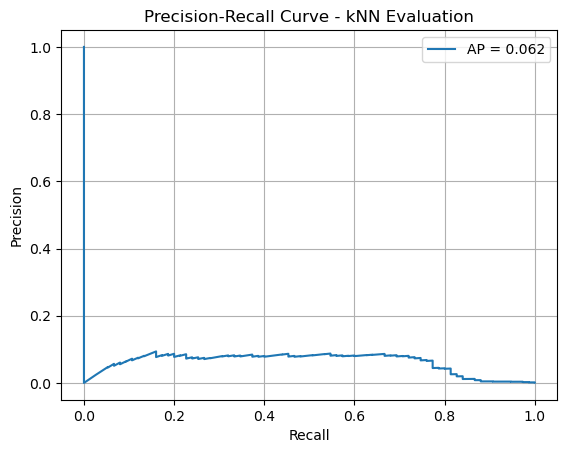

In [26]:
knn_results = evaluate_binary_classifier(
    knn_output['y_true'], 
    knn_output['y_pred'], 
    knn_output['scores'],
    method_name="kNN Evaluation"
)

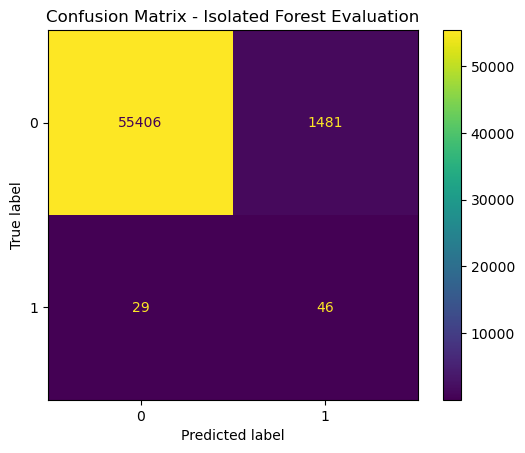

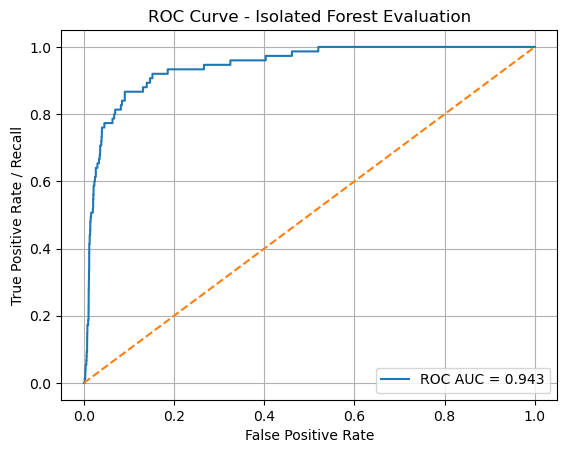

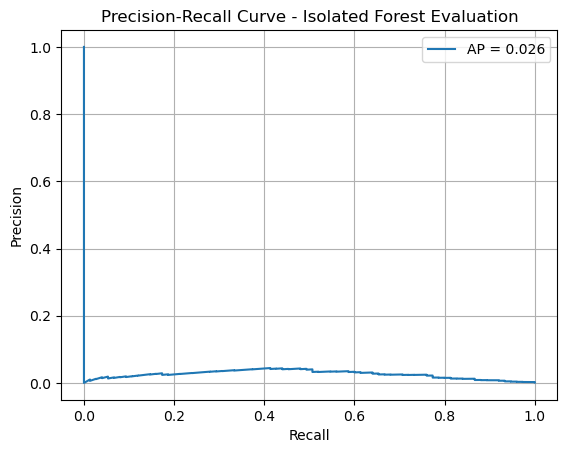

In [27]:
if_results = evaluate_binary_classifier(
    if_output['y_true'], 
    if_output['y_pred'], 
    if_output['scores'],
    method_name="Isolated Forest Evaluation"
)

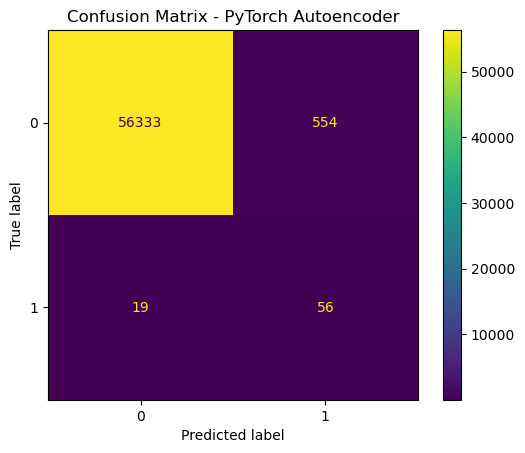

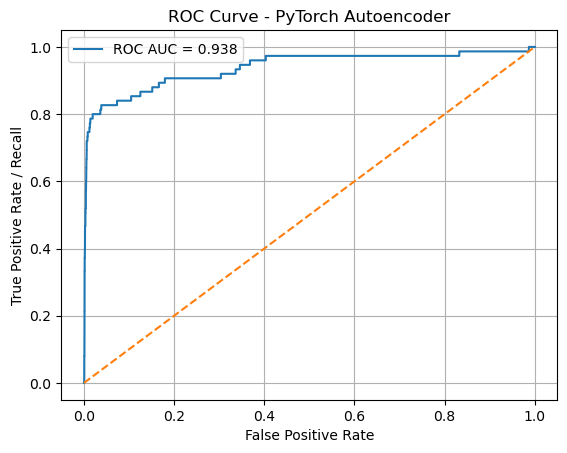

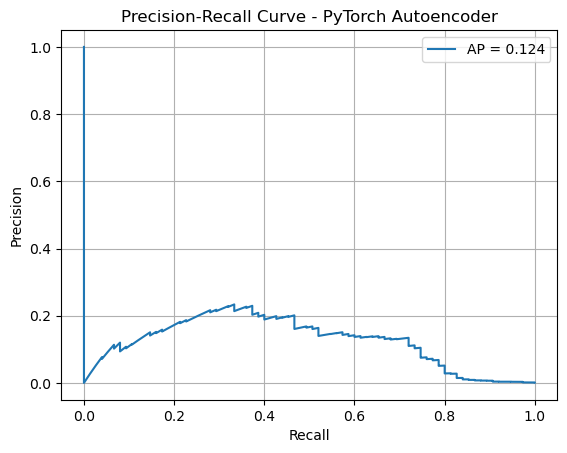

In [47]:
ac_results = evaluate_binary_classifier(
    y_true=ac_output["y_true"],
    y_pred=ac_output["y_pred"],
    scores=ac_output["scores"],
    plot=True,
    log_mlflow=True,
    method_name="PyTorch Autoencoder",
    run_name="PyTorch_Autoencoder"
)

## 5. Interpretability

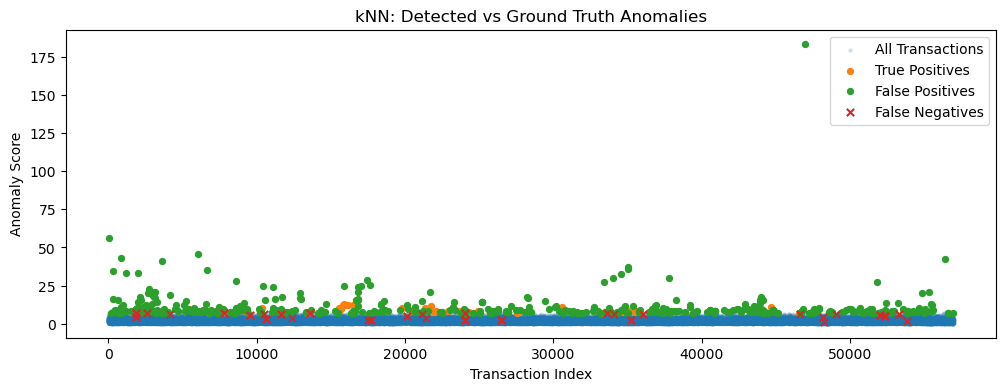

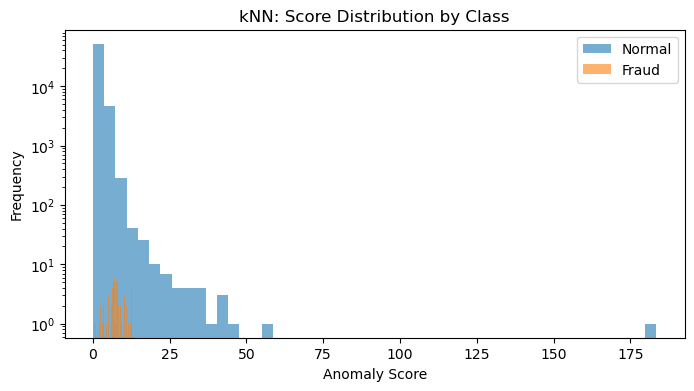

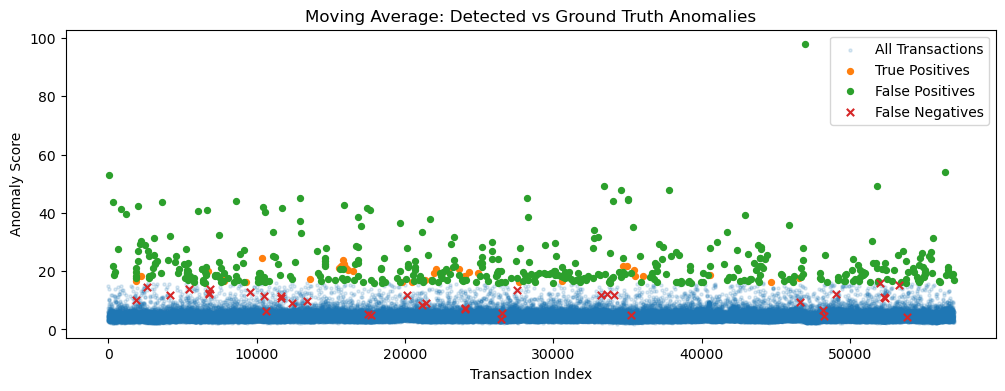

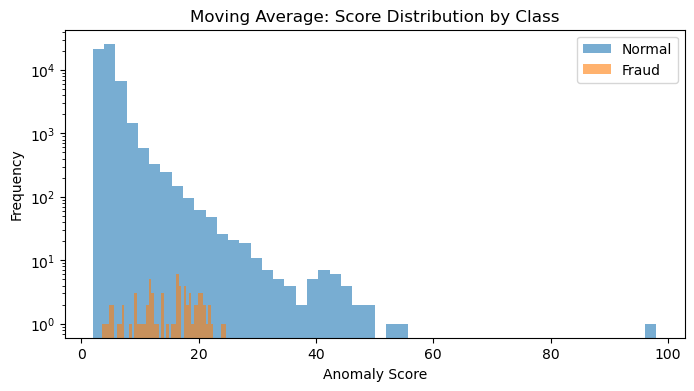

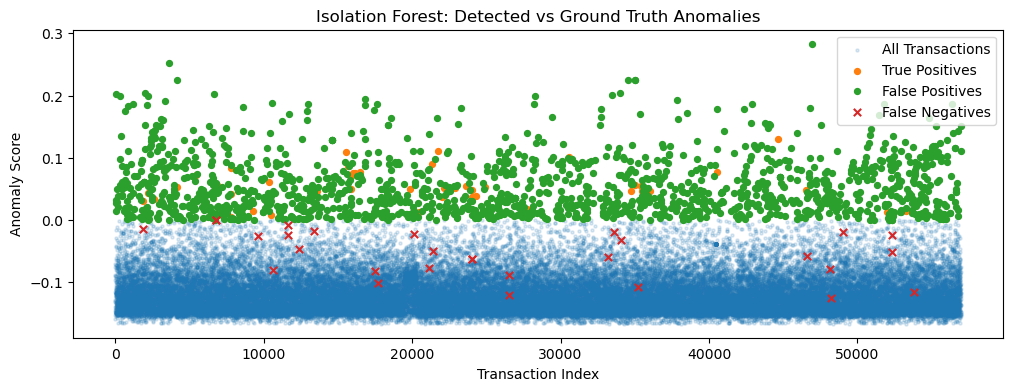

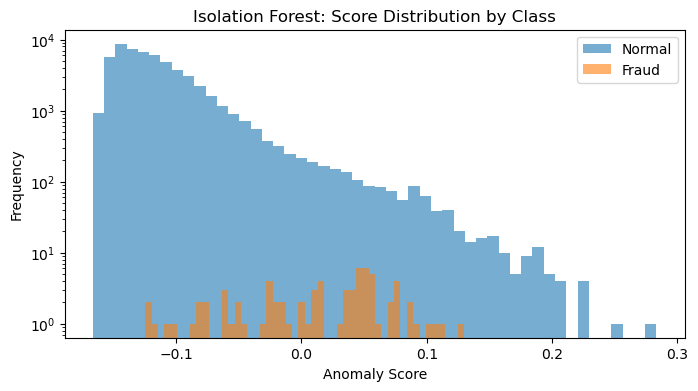

,actual_class,predicted_anomaly,anomaly_score
46926,0,1,0.283309
3609,0,1,0.252137
4169,0,1,0.225608
34998,0,1,0.225574
34533,0,1,0.225255
34994,0,1,0.224579
33998,0,1,0.204744
2014,0,1,0.204694
6674,0,1,0.202573
76,0,1,0.202538


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_detected_vs_truth(output, title):
    y_true = np.array(output["y_true"])
    y_pred = np.array(output["y_pred"])
    scores = np.array(output["scores"])

    x = np.arange(len(scores))

    tp = (y_true == 1) & (y_pred == 1)
    fp = (y_true == 0) & (y_pred == 1)
    fn = (y_true == 1) & (y_pred == 0)

    plt.figure(figsize=(12, 4))

    # All transactions
    plt.scatter(x, scores, alpha=0.15, s=5, label="All Transactions")

    # Correctly detected fraud
    plt.scatter(x[tp], scores[tp], s=18, label="True Positives")

    # False alarms
    plt.scatter(x[fp], scores[fp], s=18, label="False Positives")

    # Missed fraud
    plt.scatter(x[fn], scores[fn], s=28, marker="x", label="False Negatives")

    plt.title(title)
    plt.xlabel("Transaction Index")
    plt.ylabel("Anomaly Score")
    plt.legend()
    plt.show()


def plot_score_by_class(output, title):
    y_true = np.array(output["y_true"])
    scores = np.array(output["scores"])

    plt.figure(figsize=(8, 4))

    # Compare normal vs fraud score distributions
    plt.hist(scores[y_true == 0], bins=50, alpha=0.6, label="Normal")
    plt.hist(scores[y_true == 1], bins=50, alpha=0.6, label="Fraud")

    plt.title(title)
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.legend()
    plt.show()


def show_top_anomalies(output, n=10):
    results_df = pd.DataFrame({
        "actual_class": output["y_true"],
        "predicted_anomaly": output["y_pred"],
        "anomaly_score": output["scores"]
    })

    return results_df.sort_values(by="anomaly_score", ascending=False).head(n)

plot_detected_vs_truth(
    knn_output,
    "kNN: Detected vs Ground Truth Anomalies"
)

plot_score_by_class(
    knn_output,
    "kNN: Score Distribution by Class"
)

show_top_anomalies(knn_output)

plot_detected_vs_truth(
    ma_output,
    "Moving Average: Detected vs Ground Truth Anomalies"
)

plot_score_by_class(
    ma_output,
    "Moving Average: Score Distribution by Class"
)

show_top_anomalies(ma_output)

plot_detected_vs_truth(
    if_output,
    "Isolation Forest: Detected vs Ground Truth Anomalies"
)

plot_score_by_class(
    if_output,
    "Isolation Forest: Score Distribution by Class"
)

show_top_anomalies(if_output)

## 6. Experiment Tracking